In [ ]:
import random
import string

In [ ]:
from tqdm import tqdm

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

from sklearn.metrics import accuracy_score

cuda


# Подготовка данных

In [ ]:
ALPHABET = string.ascii_lowercase + " "
VOCAB_SIZE = len(ALPHABET)
SHIFT = 10
SEQ_LEN = 20

CLASS_TO_IDX = {char: idx for idx, char in enumerate(ALPHABET)}
IDX_TO_CLASS = {idx: char for char, idx in CLASS_TO_IDX.items()}


def encrypt(text, shift):
    encrypted = ""
    for char in text:
        if char in ALPHABET:
            new_idx = (CLASS_TO_IDX[char] + shift) % VOCAB_SIZE
            encrypted += IDX_TO_CLASS[new_idx]
        else:
            encrypted += char
    return encrypted

In [ ]:
class CaesarDataset(Dataset):
    def __init__(self, num_samples, seq_len):
        self.samples = []
        for _ in range(num_samples):
            target_text = ''.join(random.choice(ALPHABET) for _ in range(seq_len))
            input_text = encrypt(target_text, SHIFT)
            input_indices = [CLASS_TO_IDX[c] for c in input_text]
            target_indices = [CLASS_TO_IDX[c] for c in target_text]
            self.samples.append((torch.tensor(input_indices), torch.tensor(target_indices)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

train_dataset = CaesarDataset(10000, SEQ_LEN)
val_dataset = CaesarDataset(2000, SEQ_LEN)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# Модель и обучение

In [ ]:
class CaesarClassifier(nn.Module):
    def __init__(self, vocab_size, hidden_dim=64):
        super().__init__()
        self.rnn = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = x.float()
        x = x.unsqueeze(-1)

        out, _ = self.rnn(x)
        logits = self.classifier(out)
        return logits

In [ ]:
class CaesarClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=16, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        out, _ = self.rnn(embedded)
        logits = self.classifier(out)
        return logits


In [ ]:
model = CaesarClassifier(vocab_size=VOCAB_SIZE).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-2, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
def train_epoch(loader):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc='Training')
    for inputs, targets in pbar:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs.view(-1, VOCAB_SIZE), targets.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)

        preds = torch.argmax(outputs, dim=-1)
        all_preds.append(preds.view(-1).cpu())
        all_labels.append(targets.view(-1).cpu())

        pbar.set_postfix({'Loss': f'{total_loss / len(loader.dataset):.4f}'})

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)

    return total_loss / len(loader.dataset), acc

def validate(loader):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for inputs, targets in pbar:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs.view(-1, VOCAB_SIZE), targets.view(-1))

            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=-1)
            all_preds.append(preds.view(-1).cpu())
            all_labels.append(targets.view(-1).cpu())

            pbar.set_postfix({'Loss': f'{total_loss / len(loader.dataset):.4f}'})

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)

    return total_loss / len(loader.dataset), acc

In [ ]:
EPOCHS = 1
best_val_acc = 0.0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 50)

    train_loss, train_acc = train_epoch(train_loader)
    val_loss, val_acc = validate(val_loader)

    scheduler.step()

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Saved best model with val accuracy: {val_acc:.4f}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")


Epoch 1/1
--------------------------------------------------


Validation: 100%|██████████| 16/16 [00:00<00:00, 363.15it/s, Loss=0.0029]

Train Loss: 0.5138, Train Acc: 0.9522
Val Loss: 0.0029, Val Acc: 1.0000
Saved best model with val accuracy: 1.0000

Best validation accuracy: 1.0000


# Проверка работы

In [ ]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

CaesarClassifier(
  (embedding): Embedding(27, 16)
  (rnn): LSTM(16, 64, batch_first=True)
  (classifier): Linear(in_features=64, out_features=27, bias=True)
)

In [ ]:
test_phrases = [
    "hello world",
    "deep learning is fun",
    "recurrent neural network",
    "caesar cipher decoded"
]

predictions = []

for phrase in tqdm(test_phrases, desc='Predicting'):
    ciphered = encrypt(phrase, SHIFT)
    input_indices = [CLASS_TO_IDX.get(c, 0) for c in ciphered]
    frames_tensor = torch.tensor([input_indices]).to(DEVICE)

    with torch.no_grad():
        outputs = model(frames_tensor)
        preds = torch.argmax(outputs, dim=-1).squeeze().cpu().tolist()

    if isinstance(preds, int):
        preds = [preds]

    decrypted_text = "".join([IDX_TO_CLASS[idx] for idx in preds])

    print({
        'original': phrase,
        'ciphered': ciphered,
        'decrypted': decrypted_text
    })

Predicting: 100%|██████████| 4/4 [00:00<00:00, 868.21it/s]

{'original': 'hello world', 'ciphered': 'rovvyjfyavn', 'decrypted': 'hello world'}
{'original': 'deep learning is fun', 'ciphered': 'noozjvokaxsxqjsbjpdx', 'decrypted': 'deep learning is fun'}
{'original': 'recurrent neural network', 'ciphered': 'aomdaaoxcjxodakvjxocfyau', 'decrypted': 'recurrent neural network'}
{'original': 'caesar cipher decoded', 'ciphered': 'mkobkajmszroajnomynon', 'decrypted': 'caesar cipher decoded'}


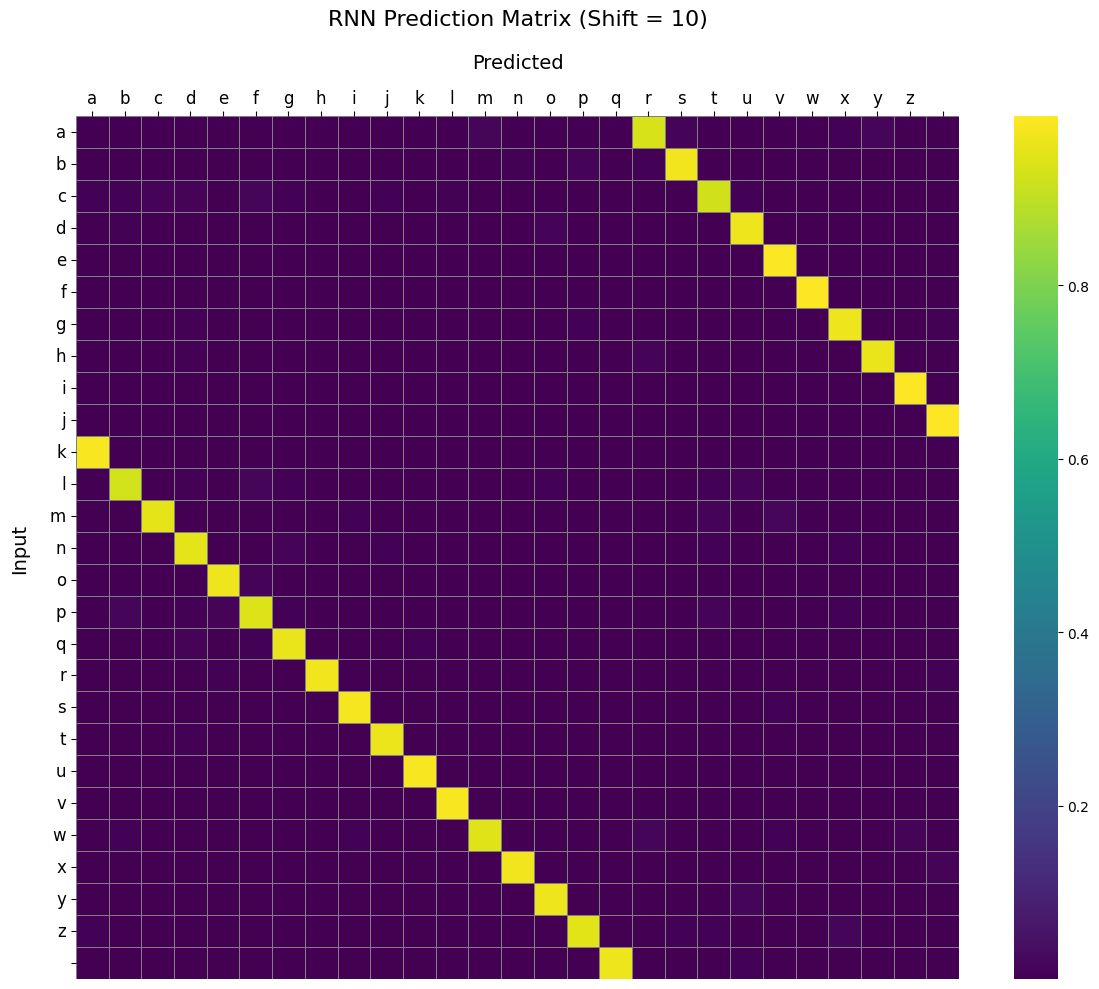

In [ ]:
def plot_prediction_matrix(model):
    model.eval()
    all_chars_tensor = torch.arange(VOCAB_SIZE).unsqueeze(1).to(DEVICE)

    with torch.no_grad():
        logits = model(all_chars_tensor)
        probs = torch.softmax(logits, dim=-1).squeeze(1).cpu().numpy()

    plt.figure(figsize=(12, 10))
    ax = sns.heatmap(
        probs,
        cmap='viridis',
        xticklabels=list(ALPHABET),
        yticklabels=list(ALPHABET),
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f'RNN Prediction Matrix (Shift = {SHIFT})', fontsize=16, pad=20)
    plt.xlabel('Predicted', fontsize=14, labelpad=15)
    plt.ylabel('Input', fontsize=14, labelpad=15)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0)
    plt.tight_layout()
    plt.savefig('heatmap.png')
    plt.show()

plot_prediction_matrix(model)